# Global Search Agent — Evaluation Plots
Leest MLflow runs uit en plot metrics voor thesis.

In [12]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [13]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})
print("ok")
# Pas dit pad aan als je mlflow.db ergens anders staat
mlflow.set_tracking_uri('sqlite:///C:/Users/AALB/Desktop/mp/graph/graphxmaf/mlflow.db')
EXPERIMENT = 'graphxmaf-eval'

ok


In [14]:
# ── Laad alle child runs ──────────────────────────────────────────────
experiment = mlflow.get_experiment_by_name(EXPERIMENT)
all_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string='tags.mlflow.parentRunId != ""',
    output_format='pandas',
)

# Handige kolommen hernoemen
df = all_runs.rename(columns={
    'metrics.llm_score': 'llm_score',
    'metrics.routing_score': 'routing_score',
    'metrics.latency_s': 'latency_s',
    'metrics.total_tokens': 'total_tokens',
    'metrics.input_tokens': 'input_tokens',
    'metrics.output_tokens': 'output_tokens',
    'metrics.routing_precision': 'routing_precision',
    'metrics.routing_recall': 'routing_recall',
    'metrics.plan_steps': 'plan_steps',
    'metrics.parallel_ratio': 'parallel_ratio',
    'metrics.success': 'success',
    'tags.version': 'version',
    'tags.category': 'category',
    'tags.difficulty': 'difficulty',
})

print(f'Loaded {len(df)} test case runs')
print(f'Versions: {df["version"].unique()}')
print(f'Categories: {df["category"].unique()}')
df[['version', 'category', 'difficulty', 'llm_score', 'routing_score', 'latency_s', 'total_tokens']].head(15)

Loaded 40 test case runs
Versions: ['baseline']
Categories: ['cross-system' 'calendar' 'email' 'identity' 'crm' 'locations']


,version,category,difficulty,llm_score,routing_score,latency_s,total_tokens
0,baseline,cross-system,hard,5.0,5.0,18.164,11161.0
1,baseline,cross-system,hard,4.0,3.0,19.836,10301.0
2,baseline,cross-system,hard,5.0,5.0,37.435,22428.0
3,baseline,cross-system,hard,5.0,5.0,37.468,23092.0
4,baseline,cross-system,hard,2.0,4.0,17.597,9125.0
5,baseline,cross-system,hard,5.0,4.0,104.629,32564.0
6,baseline,cross-system,hard,4.0,5.0,32.392,15703.0
7,baseline,cross-system,hard,4.0,4.0,12.375,6200.0
8,baseline,cross-system,hard,4.0,5.0,48.008,24879.0
9,baseline,cross-system,hard,NaN,NaN,NaN,NaN


## 1. Token Usage per Category

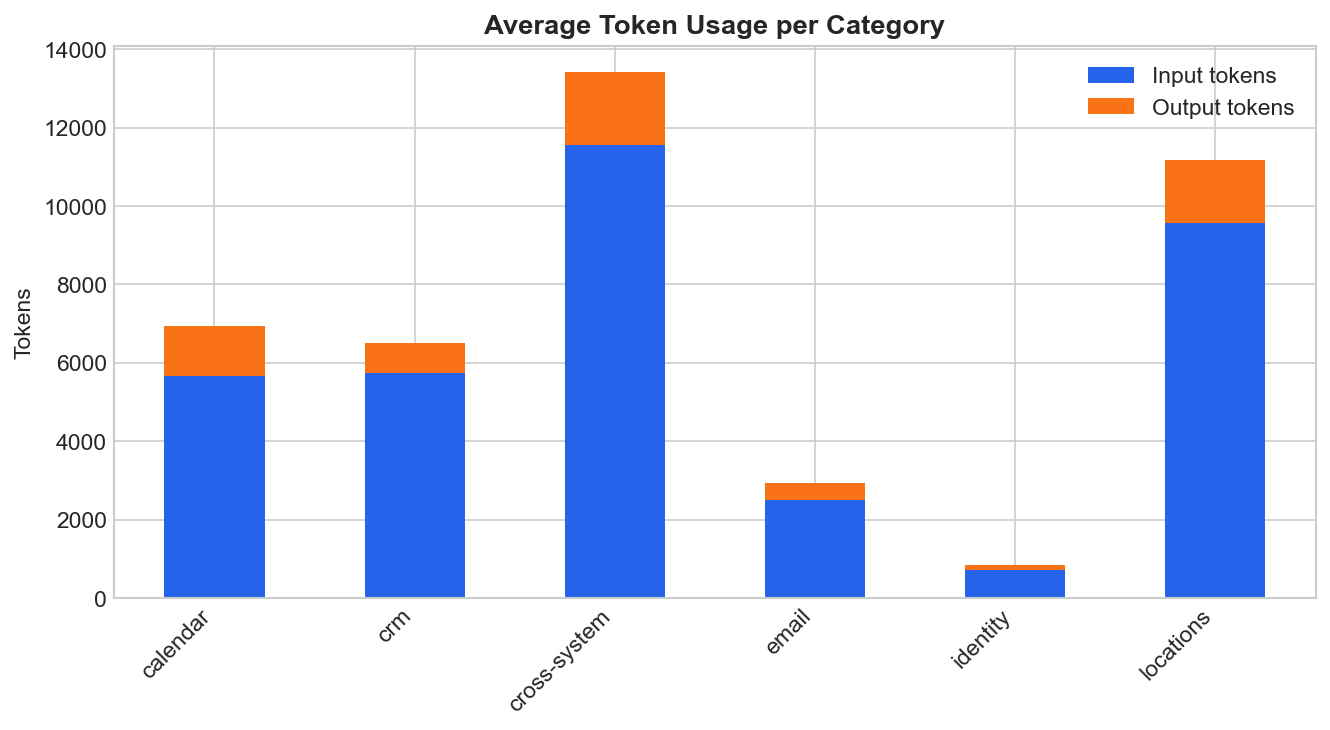

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

token_by_cat = df.groupby('category')[['input_tokens', 'output_tokens']].mean()
token_by_cat.plot(kind='bar', stacked=True, ax=ax, color=['#2563eb', '#f97316'])

ax.set_title('Average Token Usage per Category', fontweight='bold')
ax.set_ylabel('Tokens')
ax.set_xlabel('')
ax.legend(['Input tokens', 'Output tokens'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_tokens_per_category.png', bbox_inches='tight')
plt.show()

## 2. LLM Score vs Routing Score per Category

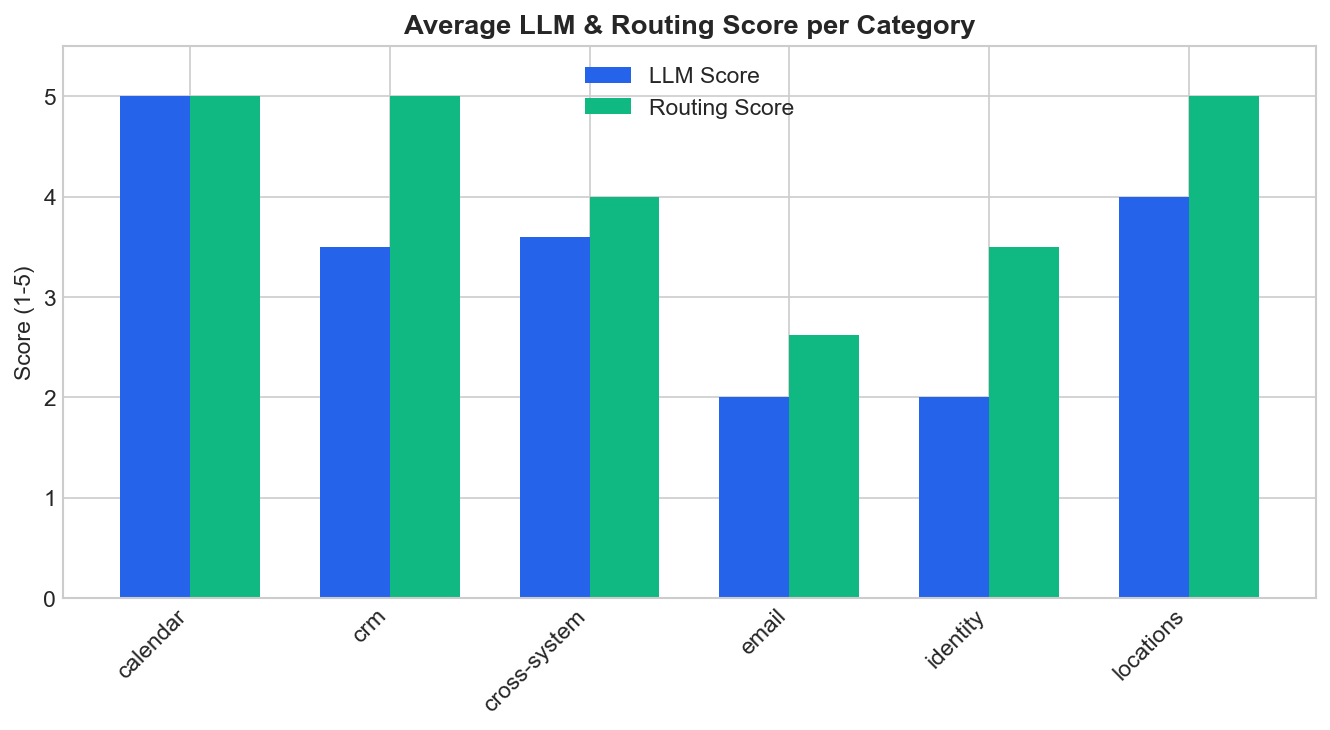

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

scores = df.groupby('category')[['llm_score', 'routing_score']].mean()
x = np.arange(len(scores))
w = 0.35

ax.bar(x - w/2, scores['llm_score'], w, label='LLM Score', color='#2563eb')
ax.bar(x + w/2, scores['routing_score'], w, label='Routing Score', color='#10b981')

ax.set_xticks(x)
ax.set_xticklabels(scores.index, rotation=45, ha='right')
ax.set_ylim(0, 5.5)
ax.set_ylabel('Score (1-5)')
ax.set_title('Average LLM & Routing Score per Category', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_scores_per_category.png', bbox_inches='tight')
plt.show()

## 3. Latency per Category

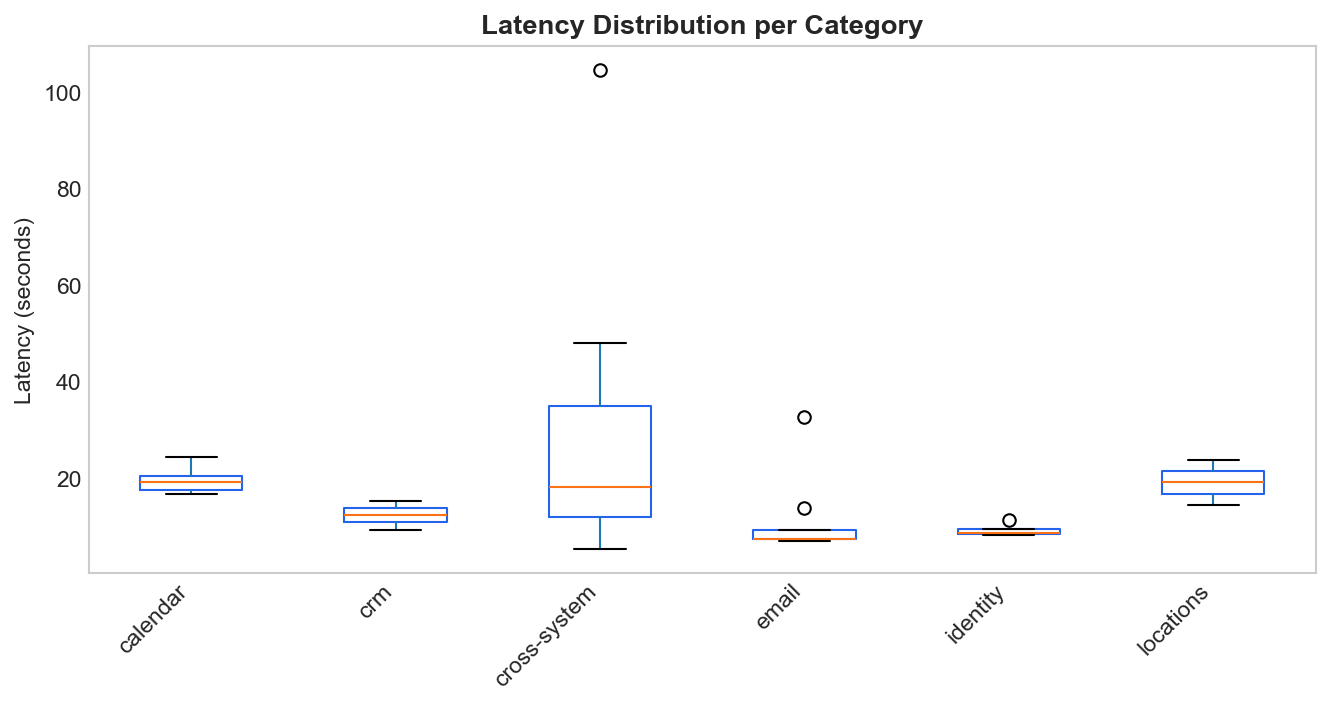

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

df.boxplot(column='latency_s', by='category', ax=ax, grid=False,
           boxprops=dict(color='#2563eb'), medianprops=dict(color='#f97316'))

ax.set_title('Latency Distribution per Category', fontweight='bold')
fig.suptitle('')
ax.set_ylabel('Latency (seconds)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_latency_per_category.png', bbox_inches='tight')
plt.show()

## 4. Latency vs Total Tokens (scatter)

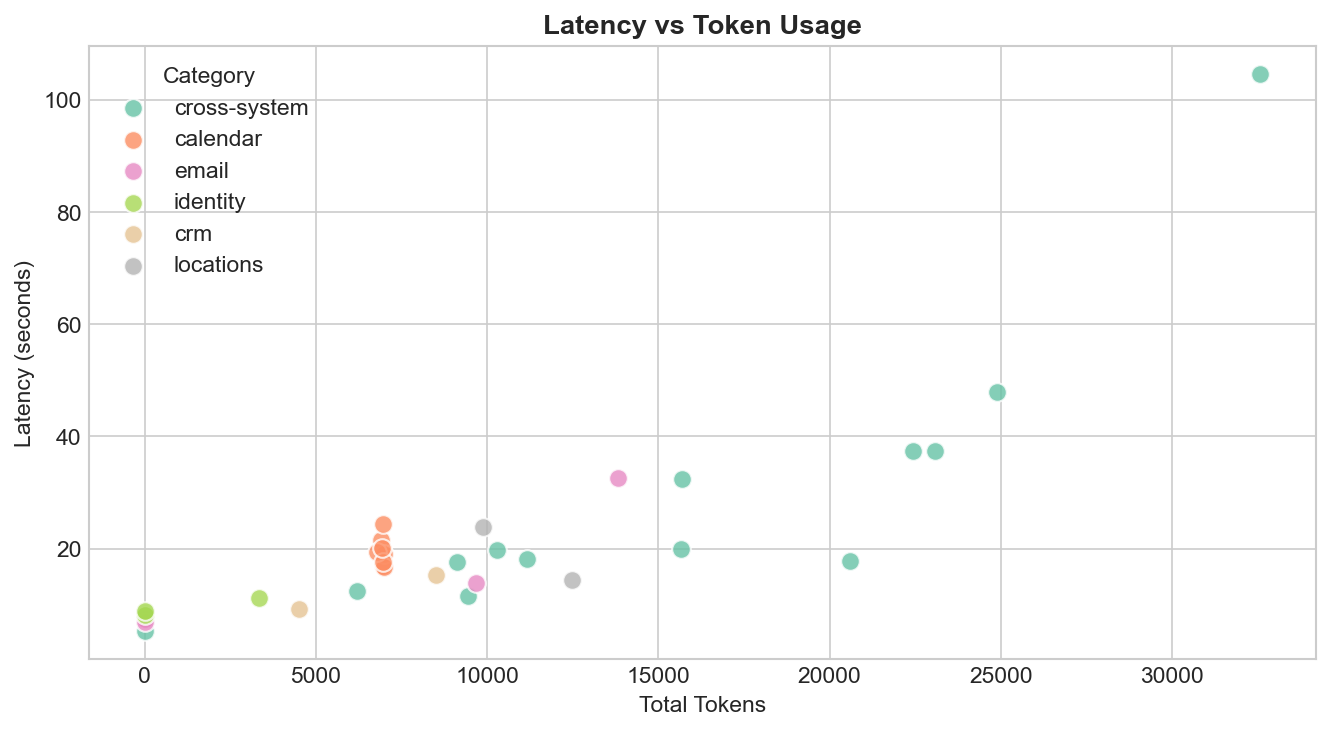

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

categories = df['category'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

for cat, color in zip(categories, colors):
    subset = df[df['category'] == cat]
    ax.scatter(subset['total_tokens'], subset['latency_s'],
               label=cat, color=color, s=80, alpha=0.8, edgecolors='white')

ax.set_xlabel('Total Tokens')
ax.set_ylabel('Latency (seconds)')
ax.set_title('Latency vs Token Usage', fontweight='bold')
ax.legend(title='Category')
plt.tight_layout()
plt.savefig('plot_latency_vs_tokens.png', bbox_inches='tight')
plt.show()

## 5. Routing Precision & Recall

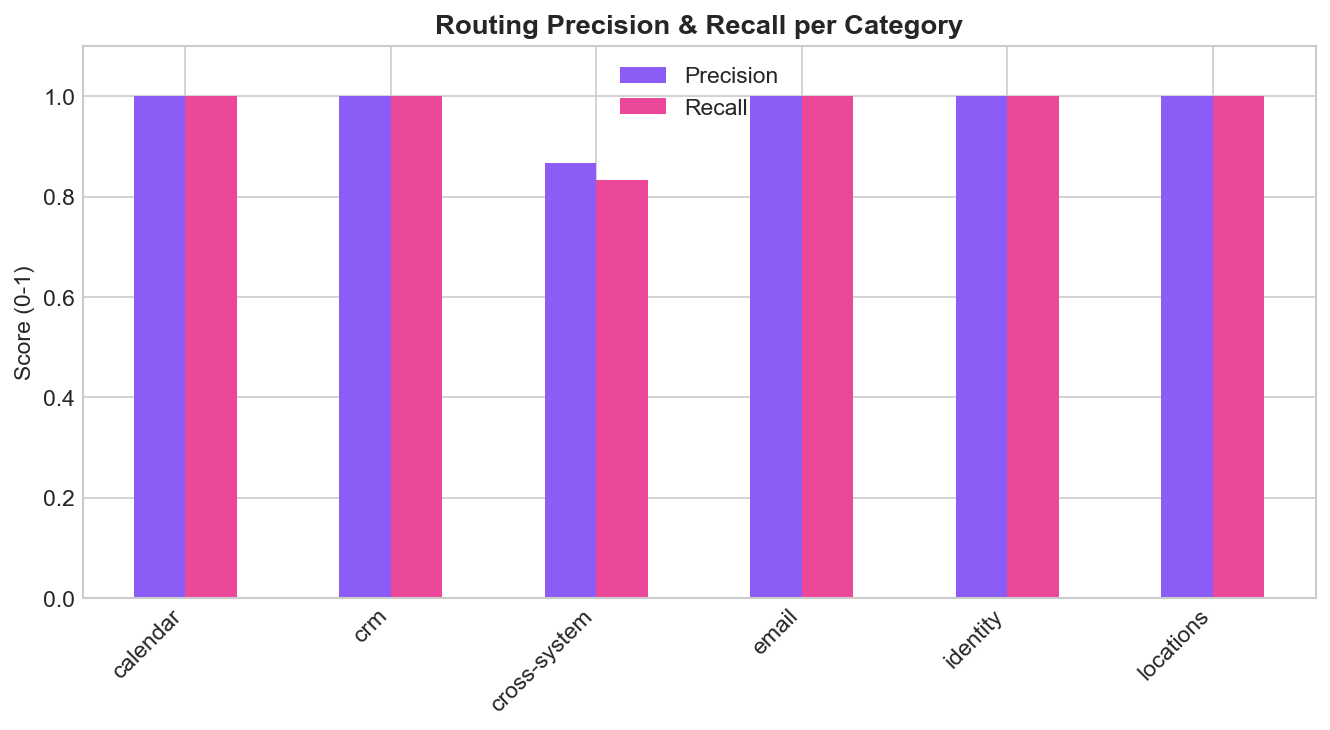

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

routing = df.groupby('category')[['routing_precision', 'routing_recall']].mean()
routing.plot(kind='bar', ax=ax, color=['#8b5cf6', '#ec4899'])

ax.set_ylim(0, 1.1)
ax.set_title('Routing Precision & Recall per Category', fontweight='bold')
ax.set_ylabel('Score (0-1)')
ax.set_xlabel('')
ax.legend(['Precision', 'Recall'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_routing_precision_recall.png', bbox_inches='tight')
plt.show()

## 6. Version Comparison (als je meerdere versions hebt)

In [20]:
if df['version'].nunique() > 1:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    compare = df.groupby('version').agg({
        'llm_score': 'mean',
        'latency_s': 'mean',
        'total_tokens': 'mean',
    })
    
    compare['llm_score'].plot(kind='bar', ax=axes[0], color='#2563eb')
    axes[0].set_title('Avg LLM Score', fontweight='bold')
    axes[0].set_ylim(0, 5.5)
    axes[0].set_ylabel('Score (1-5)')
    
    compare['latency_s'].plot(kind='bar', ax=axes[1], color='#f97316')
    axes[1].set_title('Avg Latency', fontweight='bold')
    axes[1].set_ylabel('Seconds')
    
    compare['total_tokens'].plot(kind='bar', ax=axes[2], color='#10b981')
    axes[2].set_title('Avg Total Tokens', fontweight='bold')
    axes[2].set_ylabel('Tokens')
    
    for ax in axes:
        ax.set_xlabel('')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
    
    plt.suptitle('Version Comparison', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig('plot_version_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print(f'Slechts 1 version gevonden ({df["version"].iloc[0]}). Run eerst een tweede eval met --version v1')

Slechts 1 version gevonden (baseline). Run eerst een tweede eval met --version v1


## 7. Summary Table

In [21]:
summary = df.groupby('version').agg({
    'llm_score': ['mean', 'std'],
    'routing_score': ['mean', 'std'],
    'latency_s': ['mean', 'median', lambda x: x.quantile(0.95)],
    'total_tokens': ['mean', 'sum'],
    'routing_precision': 'mean',
    'routing_recall': 'mean',
    'success': 'mean',
}).round(2)

summary.columns = [
    'LLM Score (avg)', 'LLM Score (std)',
    'Routing Score (avg)', 'Routing Score (std)',
    'Latency avg (s)', 'Latency median (s)', 'Latency p95 (s)',
    'Tokens (avg)', 'Tokens (total)',
    'Routing Precision', 'Routing Recall',
    'Success Rate',
]
summary

,LLM Score (avg),LLM Score (std),Routing Score (avg),Routing Score (std),Latency avg (s),Latency median (s),Latency p95 (s),Tokens (avg),Tokens (total),Routing Precision,Routing Recall,Success Rate
version,,,,,,,,,,,,
baseline,3.41,1.76,3.97,1.48,19.09,16.73,38.52,8175.38,318840.0,0.95,0.94,0.69
